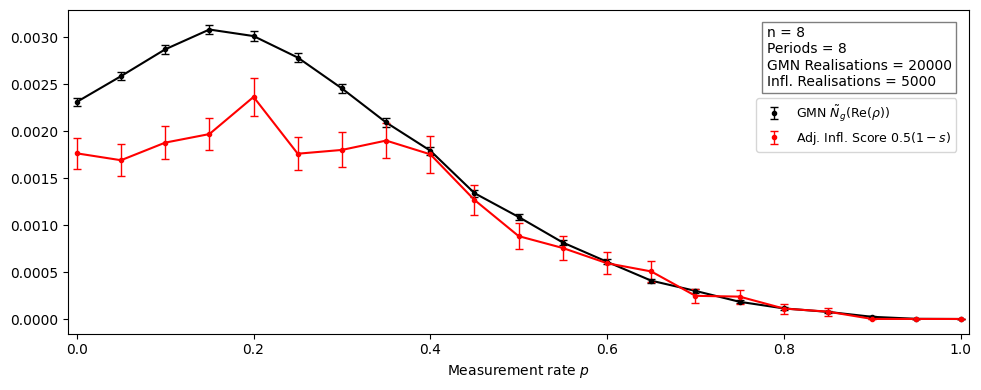

In [6]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt


# infl_reals = 5000

# # import GMN data
# df = pd.read_csv('data.csv')
# data_array = df.to_numpy().transpose()
# gmn_ps = data_array[0]
# gmn_vals = data_array[1]

# # import GMN/circuit info
# df2 = pd.read_csv('info.csv')
# data_array2 = df2.to_numpy().transpose()
# n = int(data_array2[0][0])
# periods = int(data_array2[1][0])
# realizations = int(data_array2[2][0])
# res = int(data_array2[3][0])
# p_min = float(data_array2[4][0])
# p_max = float(data_array2[5][0])

# # import inflation data
# df3 = pd.read_csv('cpp/inflation_n_8_real_5k_all.csv')
# data_array3 = df3.to_numpy().transpose()
# infl_ps = data_array3[0]
# # i_gmn_vals = data_array3[1]
# infl_scores = data_array3[2]



# # get means +/- stds for real GMN
# ps_unique = list(set(gmn_ps))
# gmn_means = []
# gmn_stds = []
# for p in ps_unique:
#     values_for_p = [val for val, p_val in zip(gmn_vals, gmn_ps) if p_val == p]
#     gmn_means.append(np.mean(values_for_p))
#     gmn_stds.append(np.std(values_for_p, ddof=1)/np.sqrt(realizations*n))

# # get means +/- stds for inflation
# infl_ps_unique = list(set(infl_ps))
# infl_means = []
# infl_stds = []
# for p in infl_ps_unique:
#     infl_values_for_p = [infl for infl, p_val in zip(infl_scores, infl_ps) if p_val == p]
#     infl_means.append(np.mean(infl_values_for_p))
#     infl_stds.append(np.std(infl_values_for_p, ddof=1)/np.sqrt(infl_reals))

sorted_pairs = sorted(zip(ps_unique, gmn_means))
x_sorted, y_sorted = zip(*sorted_pairs)
# plot GMN
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
ax1.errorbar(ps_unique, gmn_means, yerr=gmn_stds, fmt='.', color='black', ecolor='black', capsize=3, elinewidth=1, label=r"GMN $\tilde{N}_g(\text{Re}(\rho))$")
ax1.set_xlabel('Measurement rate $p$')
ax1.plot(x_sorted, y_sorted, color='black')
# ax1.set_ylabel(r'GMN $\tilde{N}_g(\rho)$ = $-\min\;\text{tr}\.(\rho W)$')

sorted_pairs = sorted(zip(infl_ps_unique, infl_means))
x_sorted, y_sorted = zip(*sorted_pairs)
# plot inflation
scale = 0.5
ax1.errorbar(infl_ps_unique, [scale*(1 - m) for m in infl_means], yerr=scale*np.array(infl_stds), 
             fmt='.', color='red', ecolor='red', capsize=3, elinewidth=1, label=f"Adj. Infl. Score ${scale}(1-s)$")
ax1.plot(x_sorted, [scale*(1-m) for m in y_sorted], color='red')


props = dict(boxstyle='square', facecolor='white', alpha=0.5)
ax1.text(0.775, 0.95, f"n = {n}\nPeriods = {periods}\nGMN Realisations = {realizations}\nInfl. Realisations = {infl_reals}", transform=ax1.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax1.set_xlim(-0.01,1.01)

fig.legend(bbox_to_anchor=(0.9675, 0.675), loc="center right", fontsize=9)
fig.tight_layout()

In [ ]:
from mipt import *
import numpy as np

from mipt_rho3_bin_writer import Rho3BinWriter, ring_subsystem_qubits

n = 8
d = 2 * n
ps = np.linspace(0.0, 1.0, 21)
realisations = 1000

subsystem_qubits = ring_subsystem_qubits(n, closed=True)

with Rho3BinWriter(
    "rho3_python_archA.bin",
    total_qubits=n,
    subsystem_qubits=subsystem_qubits,
    periods=d,
    realizations=realisations,
    p_vals=ps,
) as writer:
    for p_index, p in enumerate(ps):
        print(f"Simulating p = {p}...")
        for r in range(realisations):
            rhos = get_mipt_rho_1d(
                n, d, p,
                subsyst=3,
                all_matrices=True,
                closed=True,
            )

            writer.write_record(
                p_index=p_index,
                realization=r,
                p=float(p),
                rhos=rhos,
            )
            print(f"Realisations: {r}/{realisations}", end='\r', flush=True)
        print()

Simulating p = 0.0...
Realisations: 999/1000
Simulating p = 0.05...
Realisations: 999/1000
Simulating p = 0.1...


In [7]:
import numpy as np
print(np.linspace(0.26, 0.36, 11))
# d = 4
# print(list(range(0, 2*d+1, d)))

[0.26 0.27 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36]


Importing n = 16...
Importing n = 20...
Plotting...


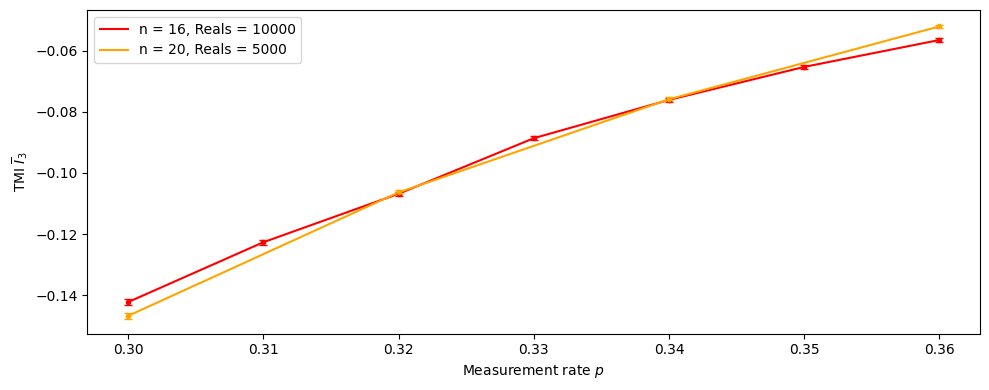

In [11]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# -----------------------
# User controls
# -----------------------
P_MIN = 0.0
P_MAX = 0.36

CHUNKSIZE = 1_000_000  # increase/decrease depending on RAM

fermion = True
reduced_gate_set = False

if fermion:
	if reduced_gate_set:
		files = [
			"cpp/tmi_fermion2c_n_8_real_10000_0.18_0.28.csv",
			"cpp/tmi_fermion2c_n_12_real_10000_0.18_0.28.csv",
			"cpp/csv/tmi/fermion2c/tmi_fermion2c_n_16_real_10000_0.18_0.28_res_21.csv",
			"cpp/csv/tmi/fermion2c/tmi_fermion2c_n_20_real_2500_0.18_0.28_res_11.csv",
			"cpp/csv/tmi/fermion2c/tmi_fermion2c_n_24_real_100_0.18_0.28_res_11.csv"
		]
		reals = [10000, 10000, 10000, 2500, 100]
		ns = [8, 12, 16, 20, 24]
    
	if not reduced_gate_set:
		files = [
            # "cpp/csv/tmi/fermion1c/tmi_fermion1c_n_12_real_7500_0.26_0.36_res_11.csv",
			"cpp/csv/tmi/fermion1c/tmi_fermion1c_n_16_real_10000_0.3_0.4_res_11.csv",
			"cpp/csv/tmi/fermion1c/tmi_fermion1c_n_20_real_5000_0.3_0.4_res_6.csv"
		]

		reals = [10000, 5000]
		ns = [16, 20]

if not fermion:
	files = [
		"cpp/csv/tmi/qubitc/tmi_qubitc_n_12_real_5000_0.1_0.3_res_11.csv",
		"cpp/csv/tmi/qubitc/tmi_qubitc_n_16_real_100_0.1_0.3_res_11.csv",
		"cpp/csv/tmi/qubitc/tmi_qubitc_n_20_real_10_0.1_0.3_res_11.csv",
        "cpp/csv/tmi/qubitc/tmi_qubitc_n_24_real_10_0.1_0.3_res_11.csv"
	]

	reals = [5000, 100, 10, 10]
	ns = [12, 16, 20, 24]

colors = ["red", "orange", "green", "blue", "purple"]


def summarize_tmi_csv_once(path, p_min=None, p_max=None, chunksize=1_000_000):
    """
    Reads the CSV once in chunks and computes mean/std-error of tmi grouped by p.

    Expected CSV columns:
        p,tmi
    """

    partials = []

    for chunk in pd.read_csv(path, usecols=["p", "tmi"], chunksize=chunksize):
        if p_min is not None:
            chunk = chunk[chunk["p"] >= p_min]
        if p_max is not None:
            chunk = chunk[chunk["p"] <= p_max]

        if chunk.empty:
            continue

        grouped = chunk.groupby("p")["tmi"].agg(
            count="count",
            sum="sum",
            sumsq=lambda x: np.square(x).sum(),
        )

        partials.append(grouped)

    if not partials:
        return np.array([]), np.array([]), np.array([])

    combined = pd.concat(partials).groupby(level=0).sum().sort_index()

    count = combined["count"].to_numpy(dtype=float)
    total = combined["sum"].to_numpy(dtype=float)
    sumsq = combined["sumsq"].to_numpy(dtype=float)

    means = total / count

    # sample variance: (sum(x^2) - sum(x)^2 / n) / (n - 1)
    variances = np.full_like(means, np.nan, dtype=float)
    valid = count > 1
    variances[valid] = (sumsq[valid] - total[valid] ** 2 / count[valid]) / (count[valid] - 1)

    stds = np.sqrt(np.maximum(variances, 0.0))
    stderrs = stds / np.sqrt(count)

    ps = combined.index.to_numpy(dtype=float)

    return ps, means, stderrs


ps_arr, mean_arr, std_arr = [], [], []

for n, path in zip(ns, files):
    print(f"Importing n = {n}...")
    ps, means, stderrs = summarize_tmi_csv_once(
        path,
        p_min=P_MIN,
        p_max=P_MAX,
        chunksize=CHUNKSIZE,
    )

    ps_arr.append(ps)
    mean_arr.append(means)
    std_arr.append(stderrs)

print("Plotting...")

fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))

for i, n in enumerate(ns):
    ax1.errorbar(
        ps_arr[i],
        mean_arr[i],
        yerr=std_arr[i],
        fmt=".",
        color=colors[i],
        ecolor=colors[i],
        capsize=3,
        elinewidth=1,
    )

    ax1.plot(
        ps_arr[i],
        mean_arr[i],
        color=colors[i],
        label=f"n = {n}, Reals = {reals[i]}",
    )

ax1.set_xlabel(r"Measurement rate $p$")
ax1.set_ylabel(r"TMI $\overline{I}_3$")
ax1.legend()
fig.tight_layout()
plt.show()

Importing N = 16: cpp/gmn_n_16_real_1k.csv
Plotting...


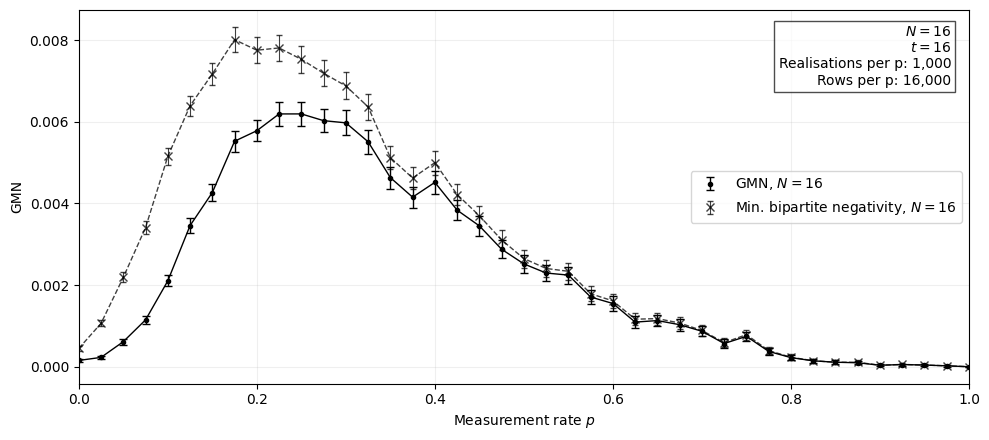

In [12]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt


# ---------------------------------------------------------------------------
# User controls
# ---------------------------------------------------------------------------

# Choose either:
#   "gmn"  for CSV columns p,gmn,bipneg
#   "fgmn" for CSV columns p,fgmn,bipneg
METRIC = "gmn"

P_MIN = 0.0
P_MAX = 1.0

CHUNKSIZE = 1_000_000  # Adjust according to available RAM.

# Plot minimum bipartite negativity alongside GMN/fGMN.
PLOT_BIPNEG = True

files = [
    "cpp/gmn_n_16_real_1k.csv",
]

# System size corresponding to each file.
ns = [16]

# Optional metadata shown in the textbox.
# Set to None to omit a field.
PERIODS = 16
REALISATIONS = 1000

colors = ["black", "red", "orange", "green", "blue"]


# ---------------------------------------------------------------------------
# Chunked CSV summarization
# ---------------------------------------------------------------------------

def summarize_column_once(
    path,
    value_column,
    p_min=None,
    p_max=None,
    chunksize=1_000_000,
):
    """
    Read a CSV once in chunks and calculate the mean and standard error of
    `value_column`, grouped by measurement rate p.

    Parameters
    ----------
    path : str or pathlib.Path
        Input CSV file.
    value_column : str
        Column to summarize, such as "gmn", "fgmn", or "bipneg".
    p_min, p_max : float or None
        Optional inclusive p-range.
    chunksize : int
        Number of CSV rows read per chunk.

    Returns
    -------
    ps : np.ndarray
        Sorted measurement rates.
    means : np.ndarray
        Mean value at each p.
    stderrs : np.ndarray
        Standard error of the mean at each p.
    counts : np.ndarray
        Number of CSV rows contributing at each p.
    """

    partials = []

    try:
        reader = pd.read_csv(
            path,
            usecols=["p", value_column],
            chunksize=chunksize,
        )
    except ValueError as error:
        raise ValueError(
            f"{path!r} does not contain the expected columns "
            f"'p' and '{value_column}'."
        ) from error

    for chunk in reader:
        # Remove malformed or non-finite entries.
        chunk["p"] = pd.to_numeric(chunk["p"], errors="coerce")
        chunk[value_column] = pd.to_numeric(
            chunk[value_column],
            errors="coerce",
        )

        chunk = chunk.replace([np.inf, -np.inf], np.nan)
        chunk = chunk.dropna(subset=["p", value_column])

        if p_min is not None:
            chunk = chunk[chunk["p"] >= p_min]

        if p_max is not None:
            chunk = chunk[chunk["p"] <= p_max]

        if chunk.empty:
            continue

        grouped = chunk.groupby("p", sort=False)[value_column].agg(
            count="count",
            total="sum",
            sumsq=lambda values: np.square(
                values.to_numpy(dtype=float)
            ).sum(),
        )

        partials.append(grouped)

    if not partials:
        empty = np.array([], dtype=float)
        return empty, empty, empty, empty

    combined = (
        pd.concat(partials)
        .groupby(level=0)
        .sum()
        .sort_index()
    )

    counts = combined["count"].to_numpy(dtype=float)
    totals = combined["total"].to_numpy(dtype=float)
    sumsquares = combined["sumsq"].to_numpy(dtype=float)

    means = totals / counts

    # Unbiased sample variance:
    #
    #     s² = [sum(x²) - sum(x)²/n] / (n - 1)
    #
    variances = np.full_like(means, np.nan, dtype=float)
    valid = counts > 1

    variances[valid] = (
        sumsquares[valid]
        - totals[valid] ** 2 / counts[valid]
    ) / (counts[valid] - 1)

    # Protect against tiny negative values caused by floating-point roundoff.
    variances[valid] = np.maximum(variances[valid], 0.0)

    standard_deviations = np.sqrt(variances)
    standard_errors = standard_deviations / np.sqrt(counts)

    ps = combined.index.to_numpy(dtype=float)

    return ps, means, standard_errors, counts


# ---------------------------------------------------------------------------
# Import and summarize
# ---------------------------------------------------------------------------

if METRIC not in {"gmn", "fgmn"}:
    raise ValueError("METRIC must be either 'gmn' or 'fgmn'.")

if len(files) != len(ns):
    raise ValueError(
        f"files and ns must have equal lengths; got "
        f"{len(files)} files and {len(ns)} system sizes."
    )

metric_ps_arr = []
metric_mean_arr = []
metric_stderr_arr = []
metric_count_arr = []

bipneg_ps_arr = []
bipneg_mean_arr = []
bipneg_stderr_arr = []

for n, path in zip(ns, files):
    print(f"Importing N = {n}: {path}")

    ps, means, stderrs, counts = summarize_column_once(
        path=path,
        value_column=METRIC,
        p_min=P_MIN,
        p_max=P_MAX,
        chunksize=CHUNKSIZE,
    )

    metric_ps_arr.append(ps)
    metric_mean_arr.append(means)
    metric_stderr_arr.append(stderrs)
    metric_count_arr.append(counts)

    if PLOT_BIPNEG:
        bipneg_ps, bipneg_means, bipneg_stderrs, _ = (
            summarize_column_once(
                path=path,
                value_column="bipneg",
                p_min=P_MIN,
                p_max=P_MAX,
                chunksize=CHUNKSIZE,
            )
        )

        bipneg_ps_arr.append(bipneg_ps)
        bipneg_mean_arr.append(bipneg_means)
        bipneg_stderr_arr.append(bipneg_stderrs)


# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------

print("Plotting...")

fig, ax = plt.subplots(figsize=(10, 4.5))

for i, n in enumerate(ns):
    color = colors[i % len(colors)]

    ps = metric_ps_arr[i]
    means = metric_mean_arr[i]
    stderrs = metric_stderr_arr[i]

    if ps.size == 0:
        print(f"Warning: no valid {METRIC} data found for N = {n}.")
        continue

    metric_label = "GMN" if METRIC == "gmn" else "fGMN"

    ax.errorbar(
        ps,
        means,
        yerr=stderrs,
        fmt=".",
        color=color,
        ecolor=color,
        capsize=3,
        elinewidth=1,
        label=rf"{metric_label}, $N={n}$",
    )

    ax.plot(
        ps,
        means,
        color=color,
        linewidth=1,
    )

    if PLOT_BIPNEG:
        bipneg_ps = bipneg_ps_arr[i]
        bipneg_means = bipneg_mean_arr[i]
        bipneg_stderrs = bipneg_stderr_arr[i]

        if bipneg_ps.size > 0:
            ax.errorbar(
                bipneg_ps,
                bipneg_means,
                yerr=bipneg_stderrs,
                fmt="x",
                color=color,
                ecolor=color,
                capsize=2,
                elinewidth=0.8,
                alpha=0.75,
                label=rf"Min. bipartite negativity, $N={n}$",
            )

            ax.plot(
                bipneg_ps,
                bipneg_means,
                color=color,
                linestyle="--",
                linewidth=1,
                alpha=0.75,
            )


# ---------------------------------------------------------------------------
# Labels and metadata
# ---------------------------------------------------------------------------

metric_name = "GMN" if METRIC == "gmn" else "fGMN"

ax.set_xlabel(r"Measurement rate $p$")
ax.set_ylabel(metric_name)
ax.set_xlim(P_MIN, P_MAX)
ax.grid(alpha=0.2)
ax.legend()

metadata_lines = []

if len(ns) == 1:
    metadata_lines.append(rf"$N={ns[0]}$")

if PERIODS is not None:
    metadata_lines.append(rf"$t={PERIODS}$")

if REALISATIONS is not None:
    metadata_lines.append(
        f"Realisations per p: {REALISATIONS:,}"
    )

# CSV row count is not necessarily the realization count because one
# realization may contribute several retained subsystems.
if len(metric_count_arr) == 1 and metric_count_arr[0].size > 0:
    minimum_rows = int(np.min(metric_count_arr[0]))
    maximum_rows = int(np.max(metric_count_arr[0]))

    if minimum_rows == maximum_rows:
        metadata_lines.append(f"Rows per p: {minimum_rows:,}")
    else:
        metadata_lines.append(
            f"Rows per p: {minimum_rows:,}–{maximum_rows:,}"
        )

if metadata_lines:
    ax.text(
        0.98,
        0.96,
        "\n".join(metadata_lines),
        transform=ax.transAxes,
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="top",
        bbox={
            "boxstyle": "square",
            "facecolor": "white",
            "alpha": 0.7,
        },
    )

fig.tight_layout()
plt.show()

Importing n = 8 from cpp/csv/tmi/rppuc/tmi_rppuc_n_8_real_100000_0.3_0.36_res_13.csv...
  loaded 13 p-values, range [0.3, 0.36]
Importing n = 12 from cpp/csv/tmi/rppuc/tmi_rppuc_n_12_real_10000_0.3_0.36_res_13.csv...
  loaded 13 p-values, range [0.3, 0.36]
Importing n = 16 from cpp/csv/tmi/rppuc/tmi_rppuc_n_16_real_20000_0.3_0.36_res_13.csv...
  loaded 13 p-values, range [0.3, 0.36]

Preparing pyfssa arrays...
p-grid alignment: tolerance matched 13 common p-values.
Common/interpolated p grid has 13 points:
[0.3   0.305 0.31  0.315 0.32  0.325 0.33  0.335 0.34  0.345 0.35  0.355
 0.36 ]

Fitting scaling collapse...
Fit success: True
p_c = 0.36 ± nan
nu  = 1.4661425 ± nan
zeta = 0 fixed
collapse quality S = 18.23318
S interpretation: S >> 10: very poor collapse under the assumed ansatz. The fitted p_c and nu should not be trusted without further checks.

Caveat: these are curvature/fit standard errors conditional on the selected finite-size scaling ansatz, p-window, system sizes, and sta

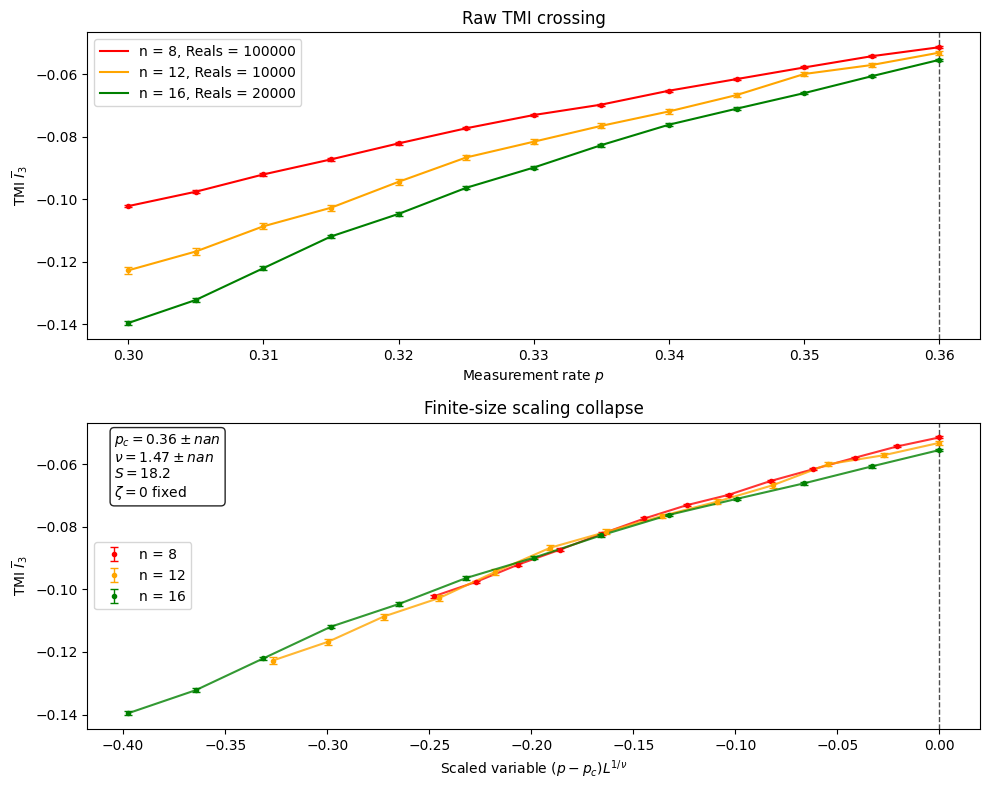

In [14]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import fssa
from scipy.optimize import minimize

# Compatibility patch for older pyfssa versions on NumPy >= 1.24
if not hasattr(np, "int"):
    np.int = int

# -----------------------
# User controls
# -----------------------
P_MIN = 0.0
P_MAX = 1.0

CHUNKSIZE = 1_000_000

circ_type = "rppu"

# p-grid alignment controls
P_TOL = 1e-6
MIN_COMMON_P_POINTS = 4
ALLOW_INTERPOLATION_FALLBACK = True

if circ_type == "mms":
    PC0 = 0.17
elif circ_type == "rfgs":
    PC0 = 0.26
elif circ_type == "qrppu" or circ_type == "rppu":
    PC0 = 0.33
else:
    raise ValueError(f"Unknown circ_type: {circ_type}")

NU0 = 2.0
ZETA0 = 0.0
FIT_ZETA = False
X_BOUNDS = None
ERR_FLOOR = 1e-12

# Curvature-error controls
CURVATURE_REL_STEP = 1e-3


if circ_type == "mms":
    files = [
        "old_cpp/csv/tmi/qubitc/tmi_qubitc_n_12_real_5000_0.1_0.3_res_11.csv",
        "old_cpp/csv/tmi/qubitc/tmi_qubitc_n_16_real_100_0.1_0.3_res_11.csv",
        "old_cpp/csv/tmi/qubitc/tmi_qubitc_n_20_real_10_0.1_0.3_res_11.csv",
        "old_cpp/csv/tmi/qubitc/tmi_qubitc_n_24_real_10_0.1_0.3_res_11.csv",
    ]

    reals = [5000, 100, 10, 10]
    ns = [12, 16, 20, 24]

elif circ_type == "rfgs":
    files = [
        "cpp/csv/tmi/fermion2c/tmi_fermion2c_n_12_real_10000_0.3_0.5_res_11.csv",
        "cpp/csv/tmi/fermion2c/tmi_fermion2c_n_16_real_10000_0.3_0.5_res_11.csv",
        "cpp/csv/tmi/fermion2c/tmi_fermion2c_n_20_real_1000_0.3_0.5_res_11.csv",
    ]

    reals = [10000, 10000, 1000]
    ns = [12, 16, 20]

elif circ_type == "qrppu":
    files = [
        "old_cpp/csv/tmi/qrppuc/tmi_qrppuc_n_8_real_10000_0.3_0.4_res_11.csv",
        "old_cpp/csv/tmi/qrppuc/tmi_qrppuc_n_12_real_10000_0.3_0.4_res_11.csv",
        "old_cpp/csv/tmi/qrppuc/tmi_qrppuc_n_16_real_10000_0.3_0.4_res_11.csv",
    ]

    reals = [10000, 10000, 10000]
    ns = [8, 12, 16]

elif circ_type == "rppu":
    files = [
        "cpp/csv/tmi/rppuc/tmi_rppuc_n_8_real_100000_0.3_0.36_res_13.csv",
        "cpp/csv/tmi/rppuc/tmi_rppuc_n_12_real_10000_0.3_0.36_res_13.csv",
        "cpp/csv/tmi/rppuc/tmi_rppuc_n_16_real_20000_0.3_0.36_res_13.csv",
        # "cpp/csv/tmi/rppuc/tmi_rppuc_n_20_real_1000_0.3_0.36_res_13.csv",
    ]

    reals = [100_000, 10_000, 20_000]#, 1000]
    ns = [8, 12, 16]#, 20]


assert len(files) == len(ns) == len(reals), "files, ns, and reals must have the same length."

colors = ["red", "orange", "green", "blue", "purple", "brown", "black"]


def summarize_tmi_csv_once(path, p_min=None, p_max=None, chunksize=1_000_000):
    """
    Reads the CSV once in chunks and computes mean/std-error of tmi grouped by p.

    Expected CSV columns:
        p,tmi
    """
    partials = []

    for chunk in pd.read_csv(path, usecols=["p", "tmi"], chunksize=chunksize):
        if p_min is not None:
            chunk = chunk[chunk["p"] >= p_min]
        if p_max is not None:
            chunk = chunk[chunk["p"] <= p_max]

        chunk = chunk.replace([np.inf, -np.inf], np.nan).dropna(subset=["p", "tmi"])

        if chunk.empty:
            continue

        chunk["tmi2"] = chunk["tmi"] * chunk["tmi"]

        grouped = chunk.groupby("p").agg(
            count=("tmi", "count"),
            total=("tmi", "sum"),
            sumsq=("tmi2", "sum"),
        )

        partials.append(grouped)

    if not partials:
        return np.array([]), np.array([]), np.array([])

    combined = pd.concat(partials).groupby(level=0).sum().sort_index()

    count = combined["count"].to_numpy(dtype=float)
    total = combined["total"].to_numpy(dtype=float)
    sumsq = combined["sumsq"].to_numpy(dtype=float)

    means = total / count

    variances = np.full_like(means, np.nan, dtype=float)
    valid = count > 1
    variances[valid] = (sumsq[valid] - total[valid] ** 2 / count[valid]) / (count[valid] - 1)

    stds = np.sqrt(np.maximum(variances, 0.0))
    stderrs = stds / np.sqrt(count)

    ps = combined.index.to_numpy(dtype=float)

    return ps, means, stderrs


def prepare_sorted_arrays(ps_arr, mean_arr, stderr_arr):
    ps_arr = [np.asarray(ps, dtype=float) for ps in ps_arr]
    mean_arr = [np.asarray(means, dtype=float) for means in mean_arr]
    stderr_arr = [np.asarray(stderrs, dtype=float) for stderrs in stderr_arr]

    for i in range(len(ps_arr)):
        order = np.argsort(ps_arr[i])
        ps_arr[i] = ps_arr[i][order]
        mean_arr[i] = mean_arr[i][order]
        stderr_arr[i] = stderr_arr[i][order]

    return ps_arr, mean_arr, stderr_arr


def align_on_common_p_grid_with_tolerance(
    ps_arr,
    mean_arr,
    stderr_arr,
    p_tol=1e-6,
    min_points=4,
):
    """
    Align p-values across system sizes using an absolute tolerance.

    This keeps only p-values from the first dataset that have a p-value match
    within p_tol in every other dataset.
    """
    ps_arr, mean_arr, stderr_arr = prepare_sorted_arrays(ps_arr, mean_arr, stderr_arr)

    reference_ps = ps_arr[0]

    matched_indices_by_size = []

    for i_ref, p_ref in enumerate(reference_ps):
        matches = [i_ref]
        ok = True

        for j in range(1, len(ps_arr)):
            diffs = np.abs(ps_arr[j] - p_ref)
            k = int(np.argmin(diffs))

            if diffs[k] <= p_tol:
                matches.append(k)
            else:
                ok = False
                break

        if ok:
            matched_indices_by_size.append(matches)

    if len(matched_indices_by_size) < min_points:
        return None

    rho = []
    a_rows = [[] for _ in ps_arr]
    da_rows = [[] for _ in ps_arr]

    for matches in matched_indices_by_size:
        matched_ps = [ps_arr[j][idx] for j, idx in enumerate(matches)]
        rho.append(float(np.mean(matched_ps)))

        for j, idx in enumerate(matches):
            a_rows[j].append(mean_arr[j][idx])
            da_rows[j].append(stderr_arr[j][idx])

    rho = np.asarray(rho, dtype=float)
    a = np.asarray(a_rows, dtype=float)
    da = np.asarray(da_rows, dtype=float)

    da = np.where(np.isfinite(da) & (da > 0.0), da, ERR_FLOOR)

    return rho, a, da


def align_on_common_p_grid_by_interpolation(
    ps_arr,
    mean_arr,
    stderr_arr,
    min_points=4,
):
    """
    Interpolate all datasets onto a common p-grid.

    The common grid is chosen from the first dataset, restricted to the overlap
    of all datasets' p-ranges. This is useful when p grids are slightly offset
    or genuinely different.

    This adds an interpolation assumption, so exact/tolerance matching is tried first.
    """
    ps_arr, mean_arr, stderr_arr = prepare_sorted_arrays(ps_arr, mean_arr, stderr_arr)

    overlap_min = max(ps.min() for ps in ps_arr)
    overlap_max = min(ps.max() for ps in ps_arr)

    if overlap_min >= overlap_max:
        raise RuntimeError(
            "No overlapping p-range across datasets. "
            f"overlap_min={overlap_min}, overlap_max={overlap_max}"
        )

    rho = ps_arr[0][(ps_arr[0] >= overlap_min) & (ps_arr[0] <= overlap_max)]

    if rho.size < min_points:
        # If the first dataset has too few points in the overlap, use an evenly spaced grid.
        min_native_count = min(
            np.count_nonzero((ps >= overlap_min) & (ps <= overlap_max))
            for ps in ps_arr
        )
        n_grid = max(min_native_count, min_points)

        if n_grid < min_points:
            raise RuntimeError(
                f"Only {n_grid} p-points available in overlapping p-range. "
                "Need at least 4 for pyfssa."
            )

        rho = np.linspace(overlap_min, overlap_max, n_grid)

    a_rows = []
    da_rows = []

    for ps, means, stderrs in zip(ps_arr, mean_arr, stderr_arr):
        a_rows.append(np.interp(rho, ps, means))
        da_rows.append(np.interp(rho, ps, stderrs))

    a = np.asarray(a_rows, dtype=float)
    da = np.asarray(da_rows, dtype=float)

    da = np.where(np.isfinite(da) & (da > 0.0), da, ERR_FLOOR)

    return rho, a, da


def align_on_common_p_grid(
    ps_arr,
    mean_arr,
    stderr_arr,
    p_tol=1e-6,
    min_points=4,
    allow_interpolation=True,
):
    """
    First tries tolerance-based p-grid matching.
    If that fails, optionally interpolates onto a common overlapping grid.
    """
    matched = align_on_common_p_grid_with_tolerance(
        ps_arr,
        mean_arr,
        stderr_arr,
        p_tol=p_tol,
        min_points=min_points,
    )

    if matched is not None:
        rho, a, da = matched
        print(f"p-grid alignment: tolerance matched {rho.size} common p-values.")
        return rho, a, da

    print()
    print(f"Tolerance alignment found fewer than {min_points} common p-values.")
    print(f"p_tol = {p_tol:g}")

    for i, (n, ps) in enumerate(zip(ns, ps_arr)):
        ps = np.asarray(ps, dtype=float)
        print(f"n = {n}: count={ps.size}, min={ps.min():.12g}, max={ps.max():.12g}")
        print("p-values:", np.array2string(ps, precision=12, separator=", "))

    if not allow_interpolation:
        raise RuntimeError(
            "No sufficient common p-grid found, and interpolation fallback is disabled."
        )

    print()
    print("Using interpolation fallback onto the overlapping p-range.")
    rho, a, da = align_on_common_p_grid_by_interpolation(
        ps_arr,
        mean_arr,
        stderr_arr,
        min_points=min_points,
    )

    print(f"p-grid alignment: interpolated to {rho.size} common p-values.")
    print("rho:", np.array2string(rho, precision=12, separator=", "))

    return rho, a, da


def estimate_errors_from_curvature(objective, theta_hat, f_min=None, rel_step=1e-3):
    """
    Estimate parameter standard errors from the local curvature of the collapse
    quality S near the optimum.

    These are conditional fit errors, not systematic finite-size-scaling errors.
    """
    theta_hat = np.asarray(theta_hat, dtype=float)
    n_params = theta_hat.size

    if f_min is None:
        f_min = objective(theta_hat)

    steps = rel_step * np.maximum(np.abs(theta_hat), 1.0)
    hessian = np.zeros((n_params, n_params), dtype=float)

    def safe_eval(x):
        val = objective(x)
        if not np.isfinite(val):
            return np.inf
        return val

    for i in range(n_params):
        step = steps[i]

        for _ in range(12):
            xp = theta_hat.copy()
            xm = theta_hat.copy()

            xp[i] += step
            xm[i] -= step

            fp = safe_eval(xp)
            fm = safe_eval(xm)

            if np.isfinite(fp) and np.isfinite(fm):
                break

            step *= 0.5

        if not (np.isfinite(fp) and np.isfinite(fm)):
            hessian[i, i] = np.nan
        else:
            hessian[i, i] = (fp - 2.0 * f_min + fm) / step ** 2

    for i in range(n_params):
        for j in range(i + 1, n_params):
            step_i = steps[i]
            step_j = steps[j]

            for _ in range(12):
                xpp = theta_hat.copy()
                xpm = theta_hat.copy()
                xmp = theta_hat.copy()
                xmm = theta_hat.copy()

                xpp[i] += step_i
                xpp[j] += step_j

                xpm[i] += step_i
                xpm[j] -= step_j

                xmp[i] -= step_i
                xmp[j] += step_j

                xmm[i] -= step_i
                xmm[j] -= step_j

                fpp = safe_eval(xpp)
                fpm = safe_eval(xpm)
                fmp = safe_eval(xmp)
                fmm = safe_eval(xmm)

                if all(np.isfinite(v) for v in [fpp, fpm, fmp, fmm]):
                    break

                step_i *= 0.5
                step_j *= 0.5

            if not all(np.isfinite(v) for v in [fpp, fpm, fmp, fmm]):
                hessian[i, j] = np.nan
                hessian[j, i] = np.nan
            else:
                hessian[i, j] = (fpp - fpm - fmp + fmm) / (4.0 * step_i * step_j)
                hessian[j, i] = hessian[i, j]

    if not np.all(np.isfinite(hessian)):
        errors = np.full(n_params, np.nan)
        varco = np.full((n_params, n_params), np.nan)
        return errors, varco, hessian

    try:
        varco = 2.0 * f_min * np.linalg.inv(hessian)
    except np.linalg.LinAlgError:
        varco = 2.0 * f_min * np.linalg.pinv(hessian)

    diag = np.diag(varco)
    errors = np.sqrt(np.where(diag >= 0.0, diag, np.nan))

    return errors, varco, hessian


def fit_collapse_fixed_zeta(l, rho, a, da, pc0, nu0, zeta=0.0, x_bounds=None):
    """
    Fit only p_c and nu, keeping zeta fixed.
    Also reports curvature-estimated standard errors for p_c and nu.
    """
    def objective(params):
        pc, nu = params

        if not np.isfinite(pc) or not np.isfinite(nu):
            return np.inf
        if nu <= 0.0:
            return np.inf
        if pc < rho.min() or pc > rho.max():
            return np.inf

        scaled = fssa.scaledata(
            l=l,
            rho=rho,
            a=a,
            da=da,
            rho_c=pc,
            nu=nu,
            zeta=zeta,
        )

        q = fssa.quality(scaled.x, scaled.y, scaled.dy, x_bounds=x_bounds)

        if not np.isfinite(q):
            return np.inf

        return q

    res = minimize(
        objective,
        x0=np.array([pc0, nu0], dtype=float),
        method="Nelder-Mead",
        options={
            "xatol": 1e-8,
            "fatol": 1e-8,
            "maxiter": 20_000,
            "maxfev": 20_000,
        },
    )

    pc_fit, nu_fit = res.x
    q_fit = objective(res.x)

    errors, varco, hessian = estimate_errors_from_curvature(
        objective=objective,
        theta_hat=res.x,
        f_min=q_fit,
        rel_step=CURVATURE_REL_STEP,
    )

    return {
        "success": res.success,
        "message": res.message,
        "rho": pc_fit,
        "nu": nu_fit,
        "zeta": zeta,
        "drho": errors[0],
        "dnu": errors[1],
        "dzeta": 0.0,
        "errors": errors,
        "varco": varco,
        "hessian": hessian,
        "quality": q_fit,
        "raw_result": res,
    }


def classify_collapse_quality(S):
    """
    Practical interpretation of pyfssa's reduced-chi-square-like quality S.
    """
    if not np.isfinite(S):
        return "S is non-finite: the collapse fit failed or produced invalid scaled data."
    if S < 0.5:
        return (
            "S << 1: suspiciously good collapse. Error bars may be overestimated, "
            "data may be correlated, or the fit window may be too forgiving."
        )
    if S < 2.0:
        return (
            "S ~ 1: statistically reasonable collapse, assuming the standard errors "
            "and scaling ansatz are realistic."
        )
    if S < 5.0:
        return (
            "S = 2–5: marginal collapse. The result may be useful, but corrections "
            "to scaling, underestimated errors, or an overly broad p-window are likely."
        )
    if S < 10.0:
        return (
            "S = 5–10: poor collapse. Treat p_c and nu cautiously; try changing "
            "X_BOUNDS, excluding small N, or adding more data."
        )
    return (
        "S >> 10: very poor collapse under the assumed ansatz. The fitted p_c and "
        "nu should not be trusted without further checks."
    )


# -----------------------
# Load and summarize data
# -----------------------
ps_arr, mean_arr, stderr_arr = [], [], []

for n, path in zip(ns, files):
    print(f"Importing n = {n} from {path}...")

    ps, means, stderrs = summarize_tmi_csv_once(
        path,
        p_min=P_MIN,
        p_max=P_MAX,
        chunksize=CHUNKSIZE,
    )

    if ps.size == 0:
        raise RuntimeError(
            f"No usable data loaded for n = {n} from {path}. "
            f"Check that P_MIN={P_MIN} and P_MAX={P_MAX} overlap the CSV p-range."
        )

    print(f"  loaded {ps.size} p-values, range [{ps.min():.12g}, {ps.max():.12g}]")

    ps_arr.append(ps)
    mean_arr.append(means)
    stderr_arr.append(stderrs)


# -----------------------
# Prepare pyfssa arrays
# -----------------------
print()
print("Preparing pyfssa arrays...")

l = np.asarray(ns, dtype=float)

rho, a, da = align_on_common_p_grid(
    ps_arr,
    mean_arr,
    stderr_arr,
    p_tol=P_TOL,
    min_points=MIN_COMMON_P_POINTS,
    allow_interpolation=ALLOW_INTERPOLATION_FALLBACK,
)

print(f"Common/interpolated p grid has {rho.size} points:")
print(rho)


# -----------------------
# Fit scaling collapse
# -----------------------
print()
print("Fitting scaling collapse...")

if FIT_ZETA:
    res = fssa.autoscale(
        l=l,
        rho=rho,
        a=a,
        da=da,
        rho_c0=PC0,
        nu0=NU0,
        zeta0=ZETA0,
        x_bounds=X_BOUNDS,
    )

    pc_fit = res["rho"]
    nu_fit = res["nu"]
    zeta_fit = res["zeta"]

    dpc_fit = res["drho"]
    dnu_fit = res["dnu"]
    dzeta_fit = res["dzeta"]

    scaled = fssa.scaledata(
        l=l,
        rho=rho,
        a=a,
        da=da,
        rho_c=pc_fit,
        nu=nu_fit,
        zeta=zeta_fit,
    )

    collapse_quality = fssa.quality(
        scaled.x,
        scaled.y,
        scaled.dy,
        x_bounds=X_BOUNDS,
    )

    fit_success = res["success"]

else:
    res = fit_collapse_fixed_zeta(
        l=l,
        rho=rho,
        a=a,
        da=da,
        pc0=PC0,
        nu0=NU0,
        zeta=ZETA0,
        x_bounds=X_BOUNDS,
    )

    pc_fit = res["rho"]
    nu_fit = res["nu"]
    zeta_fit = res["zeta"]

    dpc_fit = res["drho"]
    dnu_fit = res["dnu"]
    dzeta_fit = res["dzeta"]

    collapse_quality = res["quality"]
    fit_success = res["success"]

    scaled = fssa.scaledata(
        l=l,
        rho=rho,
        a=a,
        da=da,
        rho_c=pc_fit,
        nu=nu_fit,
        zeta=zeta_fit,
    )

S_interpretation = classify_collapse_quality(collapse_quality)

print("Fit success:", fit_success)
print(f"p_c = {pc_fit:.8g} ± {dpc_fit:.2g}")
print(f"nu  = {nu_fit:.8g} ± {dnu_fit:.2g}")

if FIT_ZETA:
    print(f"zeta = {zeta_fit:.8g} ± {dzeta_fit:.2g}")
else:
    print(f"zeta = {zeta_fit:.8g} fixed")

print(f"collapse quality S = {collapse_quality:.8g}")
print("S interpretation:", S_interpretation)
print()
print(
    "Caveat: these are curvature/fit standard errors conditional on the selected "
    "finite-size scaling ansatz, p-window, system sizes, and standard errors. "
    "They do not include systematic uncertainty from finite-size corrections."
)


# -----------------------
# Plot
# -----------------------
print()
print("Plotting...")

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    gridspec_kw={"height_ratios": [1.0, 1.0]},
)

# Top subplot: raw TMI crossing
for i, n in enumerate(ns):
    c = colors[i % len(colors)]

    ax1.errorbar(
        ps_arr[i],
        mean_arr[i],
        yerr=stderr_arr[i],
        fmt=".",
        color=c,
        ecolor=c,
        capsize=3,
        elinewidth=1,
    )

    ax1.plot(
        ps_arr[i],
        mean_arr[i],
        color=c,
        label=f"n = {n}, Reals = {reals[i]}",
    )

ax1.axvline(pc_fit, color="black", linestyle="--", linewidth=1, alpha=0.7)

ax1.set_xlabel(r"Measurement rate $p$")
ax1.set_ylabel(r"TMI $\overline{I}_3$")
ax1.set_title("Raw TMI crossing")
ax1.legend()

# Bottom subplot: scaling collapse
for i, n in enumerate(ns):
    c = colors[i % len(colors)]

    ax2.errorbar(
        scaled.x[i],
        scaled.y[i],
        yerr=scaled.dy[i],
        fmt=".",
        color=c,
        ecolor=c,
        capsize=3,
        elinewidth=1,
        label=f"n = {n}",
    )

    ax2.plot(
        scaled.x[i],
        scaled.y[i],
        color=c,
        alpha=0.8,
    )

ax2.axvline(0.0, color="black", linestyle="--", linewidth=1, alpha=0.7)

ax2.set_xlabel(r"Scaled variable $(p - p_c)L^{1/\nu}$")
ax2.set_ylabel(
    r"Scaled TMI $L^{-\zeta/\nu}\overline{I}_3$"
    if FIT_ZETA
    else r"TMI $\overline{I}_3$"
)
ax2.set_title("Finite-size scaling collapse")
ax2.legend()

textbox = (
    rf"$p_c = {pc_fit:.4g} \pm {dpc_fit:.1g}$" "\n"
    rf"$\nu = {nu_fit:.3g} \pm {dnu_fit:.1g}$" "\n"
    rf"$S = {collapse_quality:.3g}$"
)

if FIT_ZETA:
    textbox += "\n" + rf"$\zeta = {zeta_fit:.3g} \pm {dzeta_fit:.1g}$"
else:
    textbox += "\n" + rf"$\zeta = 0$ fixed"

ax2.text(
    0.03,
    0.97,
    textbox,
    transform=ax2.transAxes,
    va="top",
    ha="left",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        edgecolor="black",
        alpha=0.85,
    ),
)

fig.tight_layout()
plt.show()

In [6]:
import numpy as np
print(np.linspace(0.0, 1.0, 101))

[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99 1.  ]


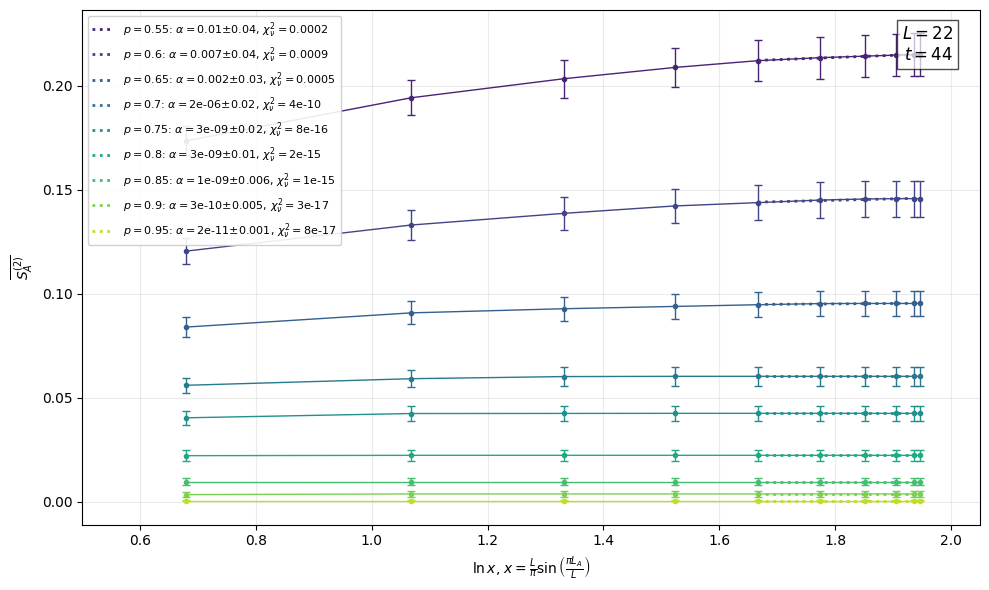

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ---------------------------------------------------------------------------
# User options
# ---------------------------------------------------------------------------

files = [
    Path(f"old_cpp/csv/entropy/n22/run1/entropy_n22_p{p}_circ2.csv")
    for p in ["0.55", "0.60", "0.65", "0.70", "0.75", "0.80", "0.85", "0.9", "0.95"]
]

# Only fit curves whose measurement rate is strictly greater than this value.
# Change ">" to ">=" below if the threshold itself should be included.
above_p = 0.3

# Exclude the first k points, ordered by increasing L_A, from each linear fit.
exclude_first_k_pts = 4

# S2_stderr is appropriate for uncertainty-weighted fits to the ensemble mean.
# S2_stddev instead represents trajectory-to-trajectory spread.
uncertainty_column = "S2_stderr"


# ---------------------------------------------------------------------------
# Weighted linear fit
# ---------------------------------------------------------------------------

def weighted_linear_fit(x, y, sigma):
    """
    Fit y = m*x + b using absolute uncertainties sigma.

    Returns
    -------
    m, b, m_stderr, b_stderr, reduced_chi_squared
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(sigma)
        & (sigma > 0.0)
    )

    x = x[valid]
    y = y[valid]
    sigma = sigma[valid]

    if x.size < 3:
        raise ValueError(
            "At least three valid points are required to calculate "
            "a linear fit and reduced chi-squared."
        )

    # Design matrix for y = m*x + b.
    design = np.column_stack((x, np.ones_like(x)))
    weights = 1.0 / sigma**2

    normal_matrix = design.T @ (weights[:, None] * design)

    try:
        covariance = np.linalg.inv(normal_matrix)
    except np.linalg.LinAlgError as exc:
        raise ValueError("Linear-fit covariance matrix is singular.") from exc

    parameters = covariance @ (design.T @ (weights * y))
    slope, intercept = parameters

    fitted_y = slope * x + intercept
    chi_squared = np.sum(((y - fitted_y) / sigma) ** 2)

    degrees_of_freedom = x.size - 2
    reduced_chi_squared = chi_squared / degrees_of_freedom

    slope_stderr = np.sqrt(covariance[0, 0])
    intercept_stderr = np.sqrt(covariance[1, 1])

    return (
        slope,
        intercept,
        slope_stderr,
        intercept_stderr,
        reduced_chi_squared,
    )


# ---------------------------------------------------------------------------
# Read files
# ---------------------------------------------------------------------------

ln_x_arr = []
mean_arr = []
std_arr = []

ns = []
periods_arr = []
ps_arr = []
realisations_arr = []
circ_types = []
circuit_names = []

for file in files:
    df = pd.read_csv(file)

    required_columns = {
        "N",
        "periods",
        "p",
        "completed_realizations",
        "circ_type",
        "circuit_name",
        "L_A",
        "ln_x",
        "S2_mean",
        uncertainty_column,
    }

    missing = required_columns.difference(df.columns)
    if missing:
        raise ValueError(
            f"{file} is missing required columns: {sorted(missing)}"
        )

    # For L_A <= L/2, sorting by L_A also sorts ln(x) monotonically.
    df = df.sort_values("L_A").reset_index(drop=True)

    ln_x_arr.append(df["ln_x"].to_numpy(dtype=float))
    mean_arr.append(df["S2_mean"].to_numpy(dtype=float))
    std_arr.append(df[uncertainty_column].to_numpy(dtype=float))

    ns.append(int(df["N"].iloc[0]))
    periods_arr.append(int(df["periods"].iloc[0]))
    ps_arr.append(float(df["p"].iloc[0]))
    realisations_arr.append(int(df["completed_realizations"].iloc[0]))
    circ_types.append(int(df["circ_type"].iloc[0]))
    circuit_names.append(str(df["circuit_name"].iloc[0]))


# Check that the compact metadata box is meaningful.
unique_ns = sorted(set(ns))
unique_periods = sorted(set(periods_arr))

if len(unique_ns) != 1:
    raise ValueError(
        f"Input CSVs do not all have the same L=N: {unique_ns}"
    )

if len(unique_periods) != 1:
    raise ValueError(
        f"Input CSVs do not all have the same t=periods: {unique_periods}"
    )


# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------

fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))

colors = plt.cm.viridis(
    np.linspace(0.1, 0.9, len(files))
)

for i, file in enumerate(files):
    x = ln_x_arr[i]
    y = mean_arr[i]
    yerr = std_arr[i]
    p = ps_arr[i]

    # Plot simulation data.
    ax1.errorbar(
        x,
        y,
        yerr=yerr,
        fmt=".",
        color=colors[i],
        ecolor=colors[i],
        capsize=3,
        elinewidth=1,
        label="_nolegend_",
    )

    # Connecting line through all simulation points.
    data_line, = ax1.plot(
        x,
        y,
        color=colors[i],
        linewidth=1,
        label="_nolegend_",
    )

    if p > above_p:
        if exclude_first_k_pts < 0:
            raise ValueError("exclude_first_k_pts must be nonnegative.")

        fit_x = x[exclude_first_k_pts:]
        fit_y = y[exclude_first_k_pts:]
        fit_sigma = yerr[exclude_first_k_pts:]

        try:
            (
                slope,
                intercept,
                slope_stderr,
                intercept_stderr,
                reduced_chi_squared,
            ) = weighted_linear_fit(
                fit_x,
                fit_y,
                fit_sigma,
            )

            # Draw the fit only across the fitted data interval.
            fit_x_line = np.linspace(
                np.min(fit_x),
                np.max(fit_x),
                200,
            )
            fit_y_line = slope * fit_x_line + intercept

            fit_label = (
                rf"$p={p:g}$: "
                rf"$\alpha=${slope:.1g}$\pm${slope_stderr:.1g}, "
                rf"$\chi_\nu^2=${reduced_chi_squared:.1g}"
            )

            ax1.plot(
                fit_x_line,
                fit_y_line,
                linestyle=":",
                linewidth=2,
                color=colors[i],
                label=fit_label,
            )

        except ValueError as exc:
            # Retain the curve in the legend when too few valid fit points exist.
            data_line.set_label(
                rf"$p={p:g}$: fit unavailable ({exc})"
            )

    else:
        # Curves below the threshold are shown but not fitted.
        data_line.set_label(
            rf"$p={p:g}$"
        )


# ---------------------------------------------------------------------------
# Compact run metadata
# ---------------------------------------------------------------------------

metadata_text = (
    rf"$L={unique_ns[0]}$"
    "\n"
    rf"$t={unique_periods[0]}$"
)

props = {
    "boxstyle": "square",
    "facecolor": "white",
    "alpha": 0.7,
}

ax1.text(
    0.97,
    0.97,
    metadata_text,
    transform=ax1.transAxes,
    fontsize=12,
    horizontalalignment="right",
    verticalalignment="top",
    bbox=props,
)


# ---------------------------------------------------------------------------
# Formatting
# ---------------------------------------------------------------------------

ax1.set_xlabel(
    r"$\ln x$, "
    r"$x=\frac{L}{\pi}\sin\left(\frac{\pi L_A}{L}\right)$"
)
ax1.set_ylabel(r"$\overline{S_A^{(2)}}$")

ax1.legend(
    fontsize=8,
    framealpha=0.9,
    loc="upper left",
)

ax1.grid(alpha=0.25)
# ax1.set_ylim(-0.05, 2.25)
ax1.set_xlim(0.5, 2.05)

fig.tight_layout()
plt.show()

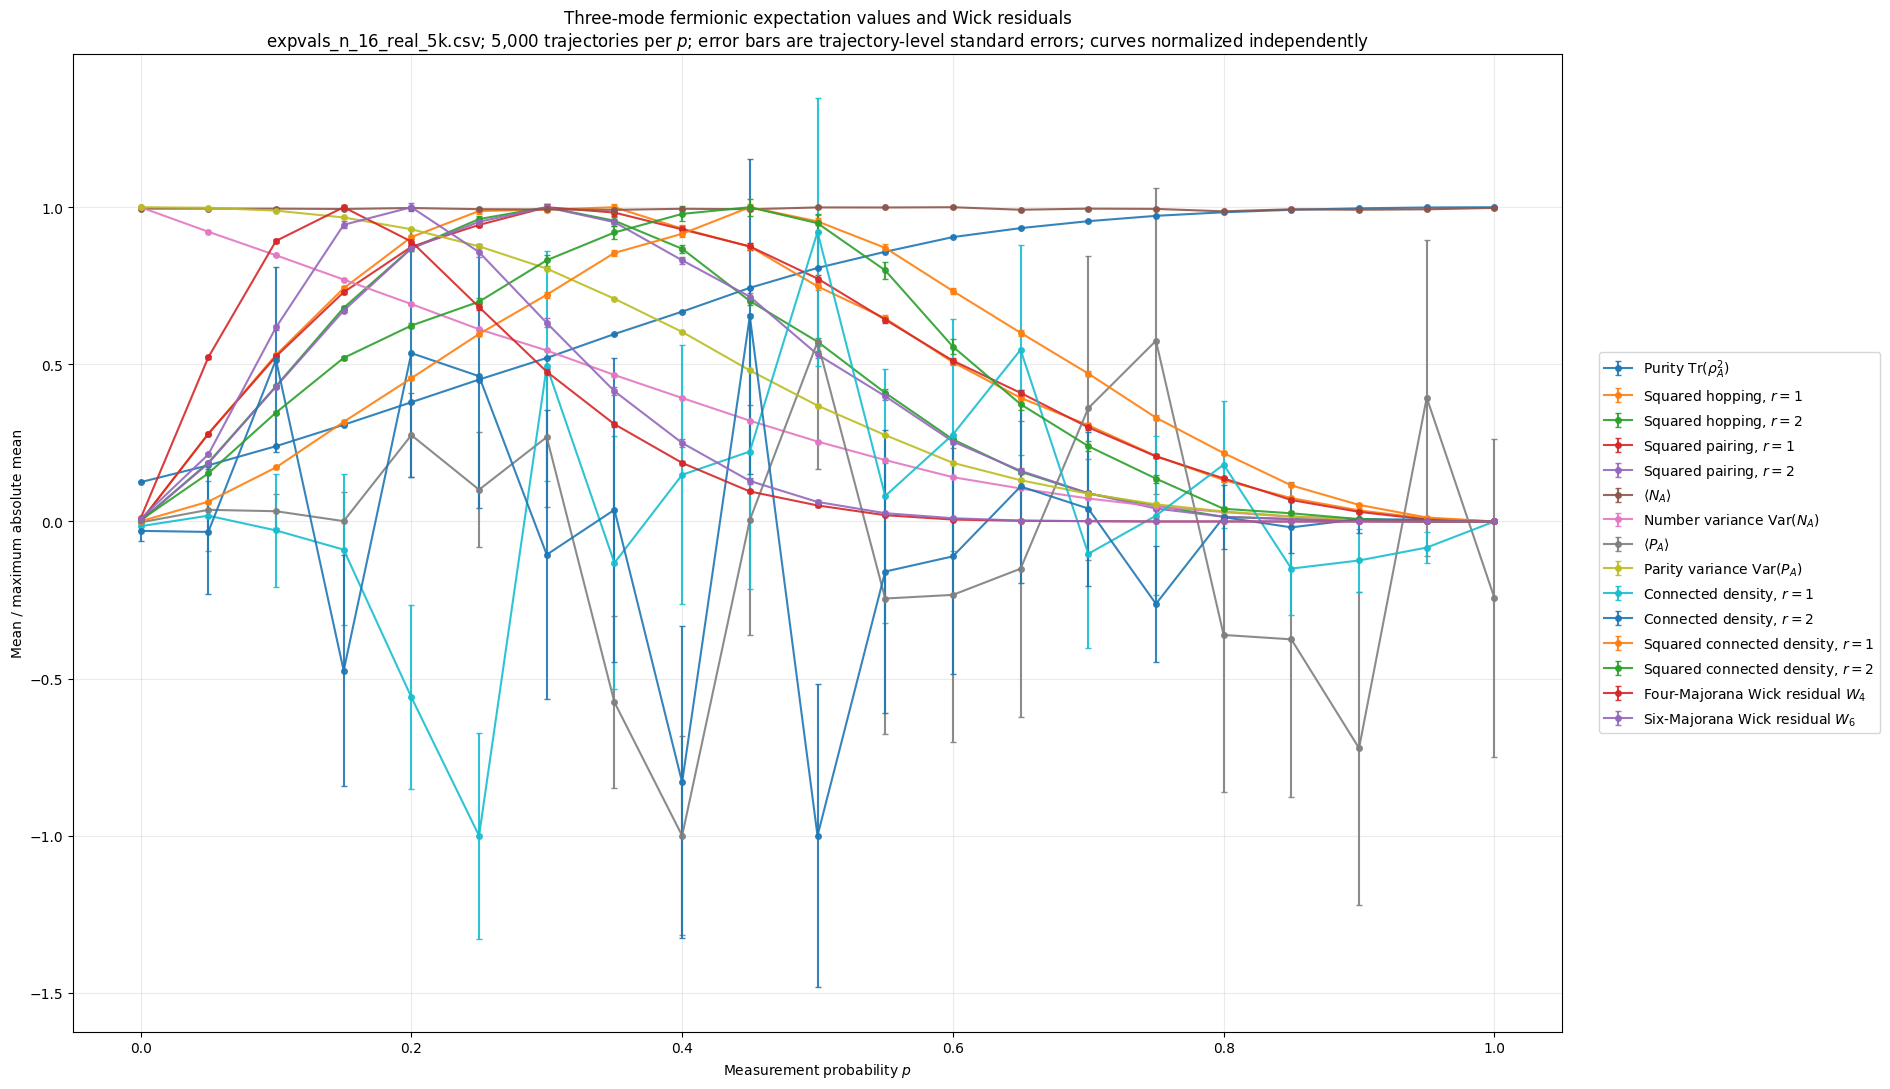

,p,p_index,realizations,subsystems_per_realization,purity_mean,purity_stderr,hop_r1_sq_mean,hop_r1_sq_stderr,hop_r2_sq_mean,hop_r2_sq_stderr,...,density_r2_mean,density_r2_stderr,density_r1_sq_mean,density_r1_sq_stderr,density_r2_sq_mean,density_r2_sq_stderr,wick4_mean,wick4_stderr,wick6_mean,wick6_stderr
0,0.00,0,5000,16,0.125118,1.326444e-07,0.000008,2.730050e-08,0.000008,2.658786e-08,...,-4.376065e-06,4.864847e-06,1.906497e-06,9.578697e-09,1.906302e-06,9.398217e-09,4.577136e-04,6.315220e-07,3.057781e-05,1.513009e-07
1,0.05,1,5000,16,0.178678,4.640159e-04,0.003574,4.384121e-05,0.000808,1.098338e-05,...,-4.866213e-06,2.915172e-05,1.995130e-04,6.057924e-06,6.584001e-05,9.585127e-07,2.452313e-02,2.334298e-04,7.761620e-04,1.314681e-05
2,0.10,2,5000,16,0.239582,7.118748e-04,0.006778,6.275441e-05,0.001858,1.845174e-05,...,7.539906e-05,4.312518e-05,5.433828e-04,1.120676e-05,1.491589e-04,2.090648e-06,4.191620e-02,3.119122e-04,2.248362e-03,2.778892e-05
3,0.15,3,5000,16,0.307698,9.660193e-04,0.009491,8.145358e-05,0.002933,2.575073e-05,...,-6.956758e-05,5.379764e-05,1.001479e-03,1.661208e-05,2.241058e-04,3.105856e-06,4.695129e-02,3.875639e-04,3.436642e-03,4.055088e-05
4,0.20,4,5000,16,0.379428,1.150297e-03,0.011574,9.458774e-05,0.003750,3.103508e-05,...,7.849491e-05,5.777245e-05,1.440615e-03,2.066181e-05,2.684288e-04,3.910451e-06,4.182427e-02,4.390464e-04,3.640377e-03,4.777373e-05
5,0.25,5,5000,16,0.451590,1.305915e-03,0.012636,1.064690e-04,0.004152,3.646917e-05,...,6.773594e-05,6.148819e-05,1.885269e-03,2.499258e-05,3.011737e-04,5.392487e-06,3.203239e-02,4.575544e-04,3.120512e-03,5.170429e-05
6,0.30,6,5000,16,0.520406,1.475640e-03,0.012692,1.127100e-04,0.004315,4.353836e-05,...,-1.546383e-05,6.724417e-05,2.279980e-03,2.850708e-05,3.579436e-04,7.291132e-06,2.237644e-02,4.166561e-04,2.300090e-03,5.199179e-05
7,0.35,7,5000,16,0.596476,1.615449e-03,0.012789,1.265698e-04,0.004130,4.790080e-05,...,5.453928e-06,7.074223e-05,2.700199e-03,3.334407e-05,3.959725e-04,8.573496e-06,1.453226e-02,3.881014e-04,1.509080e-03,4.736416e-05
8,0.40,8,5000,16,0.667756,1.705518e-03,0.011918,1.281608e-04,0.003745,5.318793e-05,...,-1.216219e-04,7.273547e-05,2.892699e-03,3.473825e-05,4.214414e-04,1.037484e-05,8.755443e-03,3.195636e-04,9.100294e-04,4.673796e-05
9,0.45,9,5000,16,0.743458,1.672815e-03,0.011189,1.349931e-04,0.003028,5.321199e-05,...,9.568437e-05,7.335669e-05,3.159742e-03,3.694681e-05,4.305752e-04,1.167181e-05,4.485164e-03,2.561475e-04,4.696340e-04,3.521080e-05


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ---------------------------------------------------------------------------
# User controls
# ---------------------------------------------------------------------------

FILE = Path("cpp/expvals_n_16_real_5k.csv")

P_MIN = 0.0
P_MAX = 1.0

# Independently normalize each observable so quantities with very different
# scales remain visible on one axis.
NORMALIZE_FOR_DISPLAY = True

FIGSIZE = (19, 11)
CAPSIZE = 2
ALPHA = 0.9


# ---------------------------------------------------------------------------
# Load aggregate output
# ---------------------------------------------------------------------------

df = pd.read_csv(FILE)
df = df.loc[df["p"].between(P_MIN, P_MAX)].sort_values("p").copy()

if df.empty:
    raise ValueError(
        f"No data remain after restricting p to [{P_MIN}, {P_MAX}]."
    )


# column base name: legend label
observables = {
    "purity": r"Purity $\mathrm{Tr}(\rho_A^2)$",
    "hop_r1_sq": r"Squared hopping, $r=1$",
    "hop_r2_sq": r"Squared hopping, $r=2$",
    "pair_r1_sq": r"Squared pairing, $r=1$",
    "pair_r2_sq": r"Squared pairing, $r=2$",
    "number_expectation": r"$\langle N_A\rangle$",
    "number_variance": r"Number variance $\mathrm{Var}(N_A)$",
    "parity_expectation": r"$\langle P_A\rangle$",
    "parity_variance": r"Parity variance $\mathrm{Var}(P_A)$",
    "density_r1": r"Connected density, $r=1$",
    "density_r2": r"Connected density, $r=2$",
    "density_r1_sq": r"Squared connected density, $r=1$",
    "density_r2_sq": r"Squared connected density, $r=2$",
    "wick4": r"Four-Majorana Wick residual $W_4$",
    "wick6": r"Six-Majorana Wick residual $W_6$",
}

required = {"p", "realizations"}
for base in observables:
    required.add(f"{base}_mean")
    required.add(f"{base}_stderr")

missing = required.difference(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")


# ---------------------------------------------------------------------------
# Prepare plotting values
# ---------------------------------------------------------------------------

plot_means = {}
plot_stderrs = {}

for base in observables:
    mean = df[f"{base}_mean"].to_numpy(dtype=float)
    stderr = df[f"{base}_stderr"].to_numpy(dtype=float)

    if NORMALIZE_FOR_DISPLAY:
        scale = np.nanmax(np.abs(mean))

        if np.isfinite(scale) and scale > 0.0:
            mean = mean / scale
            stderr = stderr / scale

    plot_means[base] = mean
    plot_stderrs[base] = stderr


# ---------------------------------------------------------------------------
# One large plot
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=FIGSIZE)

for base, label in observables.items():
    ax.errorbar(
        df["p"],
        plot_means[base],
        yerr=plot_stderrs[base],
        marker="o",
        markersize=4,
        linewidth=1.5,
        capsize=CAPSIZE,
        alpha=ALPHA,
        label=label,
    )

ax.set_xlabel("Measurement probability $p$")
ax.set_ylabel(
    "Mean / maximum absolute mean"
    if NORMALIZE_FOR_DISPLAY
    else "Observable"
)

realization_min = int(df["realizations"].min())
realization_max = int(df["realizations"].max())

if realization_min == realization_max:
    realization_text = f"{realization_min:,} trajectories per $p$"
else:
    realization_text = (
        f"{realization_min:,}–{realization_max:,} trajectories per $p$"
    )

title = (
    "Three-mode fermionic expectation values and Wick residuals\n"
    f"{FILE.name}; {realization_text}; "
    "error bars are trajectory-level standard errors"
)

if NORMALIZE_FOR_DISPLAY:
    title += "; curves normalized independently"

ax.set_title(title)
ax.grid(True, alpha=0.25)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
)

fig.tight_layout()
plt.show()


# ---------------------------------------------------------------------------
# Display the underlying unnormalized statistics
# ---------------------------------------------------------------------------

display(df)